Le taux de contagion journalier pour le covid est de 0.6 personne par jour
Le nombre de jour où une personne est contagieuse est de 5 jours
Le pourcentage de décès en France est d'environ 0.42%

Les premiers cas de COVID-19 ont été détectés en France en janvier 2020. La pandémie a été déclarée par l'OMS, le 11 mars.
https://www.santepubliquefrance.fr/maladies-et-traumatismes/maladies-et-infections-respiratoires/covid-19/le-scan/#tabs

La campagne de vaccination a débuté le 27 décembre 2020. Il s'est écoulé environ 336 jours depuis la découverte du patient 0 en France (on a pris la date du 27 janvier 2020 comme $t_0$)

Le taux de vaccination $\omega(t)$ n'est pas une constante. Il a évolué au fur à et mesure que la campagne de vaccination s'élargissait.

Pour commencer, on va supposer que ceux qui ont eu l'infection et ceux qui ont eu le vaccin, ont la même immunité dans le temps, soit 

On va combiner les modèles SIRDV et SIRD développés de sorte que 

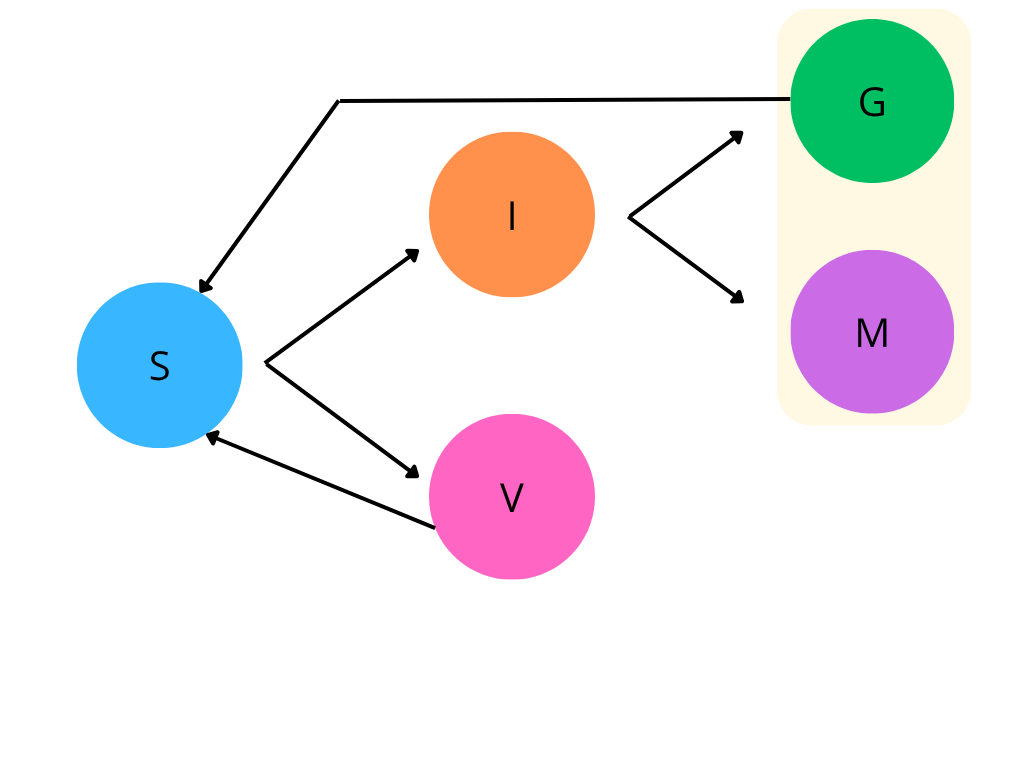



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nosPackages.mathUtils as mathUtils

# population initial
S_init=0.999 # personnes suscétibles (départ) en fraction -> 1=100%
I_init=0.001 # personnes infectés
R_init=0 # personnes guérissent
D_init=0 # personnes qui meurent
V_init=0 # personnes vaccinées

# paramètre de contagion
beta=0.558 # taux de contagion journalier de base pour le covid = 0.6 personnes/jour
gamma=0.2 # 1/gamma = nb de jour contagieux = 5 jour pour le covid
mu= 0.002 # Coefficient de décès (valeur non réelle)
omega= 0.01 # Taux de personnes vaccinées
R0=beta/(gamma)*S_init # nombre de personnes contaminés par un malade = 3 pour le covid

In [ ]:
dt = 0.1
tmax = 100.0
temps = np.arange(0, tmax + dt, dt)
n = temps.size

S = np.empty(n)
I = np.empty(n)
R = np.empty(n)
D = np.empty(n)
V = np.empty(n)
Rt = np.empty(n)

y = np.empty(5)
y[0] = S_init
y[1] = I_init
y[2] = R_init
y[3] = D_init
y[4] = V_init

params={"beta":beta, "gamma":gamma, "mu":mu, "omega":omega}
model=mathUtils.SIR(params)
deriv=model.deriv_SIRDV
euler=model.euler

for i in range(n):
    S[i] = y[0]
    I[i] = y[1]
    R[i] = y[2]
    D[i] = y[3]
    V[i] = y[4]
    t = temps[i]
    y = euler(t, dt, y, deriv)
Rt = R0*S # evolution du R0 (contagion pour une personne)

In [ ]:
"""plt.figure()
plt.title("Evolution de S(t)")
plt.plot(temps, S)
plt.xlabel("temps")
plt.ylabel("S(t)")
plt.savefig("sird_S.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de I(t)")
plt.plot(temps, I)
plt.xlabel("temps")
plt.ylabel("I(t)")
plt.savefig("sird_I.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de R(t)")
plt.plot(temps, R)
plt.xlabel("temps")
plt.ylabel("R(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de D(t)")
plt.plot(temps, D)
plt.xlabel("temps")
plt.ylabel("D(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de V(t)")
plt.plot(temps, V)
plt.xlabel("temps")
plt.ylabel("V(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de Rt")
plt.plot(temps, Rt)
plt.xlabel("temps")
plt.ylabel("Rt")
plt.savefig("sird_Rt.pdf", bbox_inches='tight')
plt.show()
"""

In [ ]:
plt.figure()
plt.title("Evolution de S(t), I(t), R(t), D(t) et Rt")

ax1 = plt.gca()
ax1.plot(temps, S, label="S(t)")
ax1.plot(temps, I, label="I(t)")
ax1.plot(temps, R, label="R(t)")
ax1.plot(temps, D, label="D(t)")
ax1.plot(temps, V, label="V(t)")
ax1.set_xlabel("temps")
ax1.set_ylabel("S(t), I(t), R(t), D(t), V(t)")
ax1.legend(loc="upper right")

ax2 = ax1.twinx()
ax2.plot(temps, Rt, "--", label="Rt")
ax2.axhline(1, linestyle=":", label="Rt = 1")
ax2.set_ylabel("Rt")
ax2.legend(loc="center right")

plt.savefig("sir_SIRDV_Rt.pdf", bbox_inches='tight')
plt.show()